In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task-1: Applying FFT on 2D Image


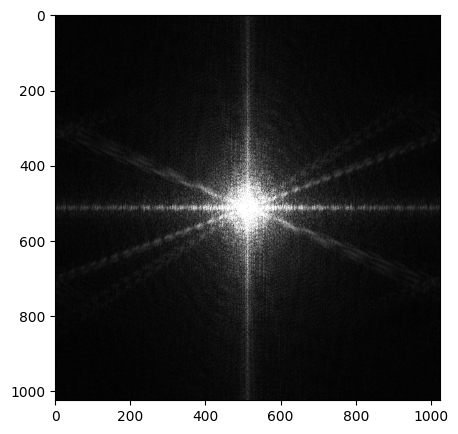

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage import io,color

# Load grayscale image Bracu.png and convert it to grayscale
image = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/Current semester materials/CSE 428/Lab Files/Lab 8/Lab Task/BracU.png'), cv2.COLOR_BGR2GRAY)


def perform_fft2(x, M, N):
    X = np.fft.fft2(x)
    X = np.fft.fftshift(X)
    X = X / (N * M)

    u = np.fft.fftshift(np.fft.fftfreq(M))
    v = np.fft.fftshift(np.fft.fftfreq(N))
    u, v = np.meshgrid(u, v)

    return X, u, v
# --- Perform FFT on the image ---
height = image.shape[0]
width = image.shape[1]
X, u, v = perform_fft2(image, height, width)

plt.figure(figsize=(5,5))
plt.imshow(np.log(np.abs(X)+1), cmap='gray', vmin=0, vmax=np.percentile(np.log(np.abs(X)+1), 99))


# Lab Task 2: Low-pass and High-pass Filtering in the Frequency Domain


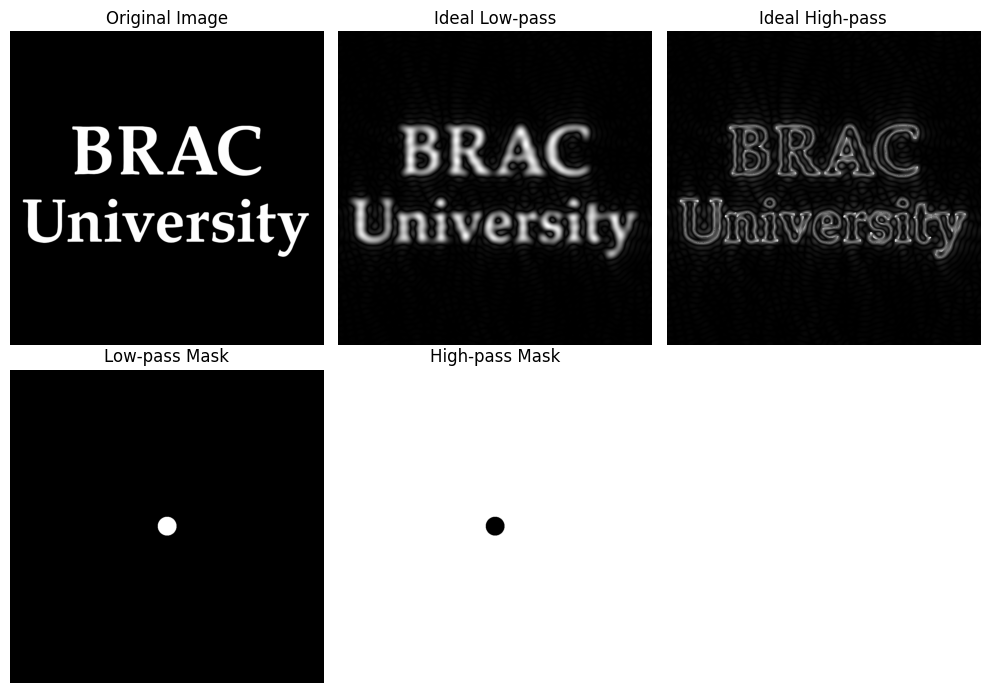

In [4]:
# Compute radial frequency grid
D = np.sqrt(u**2 + v**2)

cut_off = 0.03


# Define a low pass and a high pass filter withe the given cut_off
H_lp = np.where(D < cut_off, 1, 0)
# H_hp = np.where(D > cut_off, 1, 0)
H_hp = 1 - H_lp


# Apply filter and reconstruct the filtered images
img_lp = np.abs(np.fft.ifft2(np.fft.ifftshift(X * H_lp)))
img_hp = np.abs(np.fft.ifft2(np.fft.ifftshift(X * H_hp)))

plt.figure(figsize=(10, 7))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_lp, cmap='gray')
plt.title("Ideal Low-pass")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_hp, cmap='gray')
plt.title("Ideal High-pass")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(H_lp, cmap='gray')
plt.title("Low-pass Mask")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(H_hp, cmap='gray')
plt.title("High-pass Mask")
plt.axis('off')

plt.tight_layout()
plt.show()
